<a href="https://colab.research.google.com/github/aansikkaw/Customer-Segmentation-Churn-Prediction-System/blob/main/Customer_Segmentation_%26_Churn_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [ ]:
df.shape
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.isnull().sum()
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


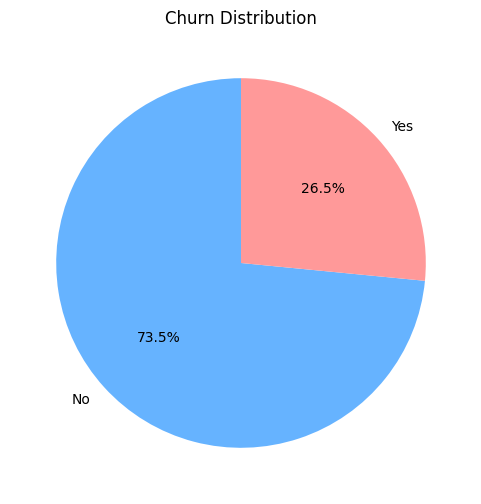

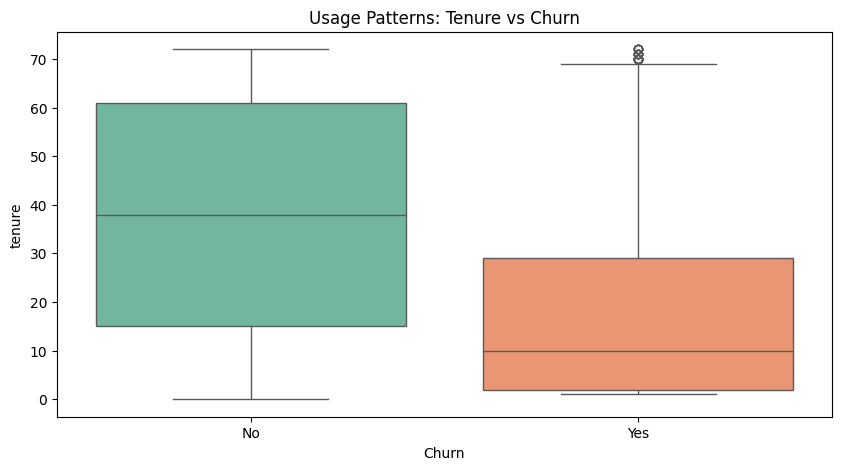

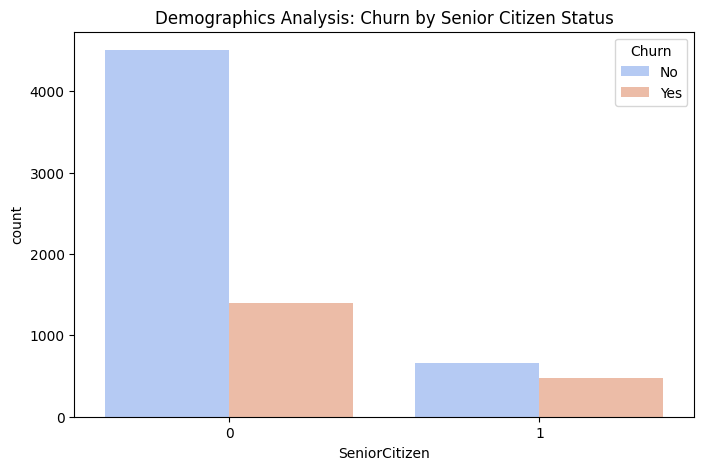

In [ ]:
plt.figure(figsize=(6, 6))
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], startangle=90)
plt.title('Churn Distribution')
plt.ylabel('')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2', hue='Churn', legend=False)
plt.title('Usage Patterns: Tenure vs Churn')
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df, palette='coolwarm')
plt.title('Demographics Analysis: Churn by Senior Citizen Status')
plt.show()

In [ ]:
# 2. Run K-Means Clustering
features_cluster = df[['tenure', 'MonthlyCharges', 'TotalCharges']]
scaler_cluster = StandardScaler()
scaled_features = scaler_cluster.fit_transform(features_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Customer_Segment'] = kmeans.fit_predict(scaled_features)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Customer_Segment
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,2
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,2
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,2
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,1
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,2


In [ ]:
print("Customer Count per Segment:")
print(df['Customer_Segment'].value_counts())
print("-" * 50)
print("Segment Profiles (Average Metrics per Group):")
segment_profiles = df.groupby('Customer_Segment')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()
print(segment_profiles)
print("\n========================================================")
print("      BUSINESS INSIGHTS FOR RETENTION OPTIMIZATION")
print("========================================================")
print("1. Segment 0: 'High-Risk New Users' (Low Tenure, High Monthly Charges)")
print("   - Strategy: These are new customers paying high monthly rates with the highest likelihood of churn.")
print("   - Action: Deploy immediate, high-touch onboarding support and usage walkthroughs to build quick product adoption.")

print("\n2. Segment 1: 'VIP / Core Revenue' (High Tenure, High Monthly Charges)")
print("   - Strategy: Long-term, high-spending loyal customers who form the financial backbone of the business.")
print("   - Action: Target exclusively with VIP loyalty rewards, early product previews, or dedicated account reps. Avoid brand-diluting discount pop-ups.")

print("\n3. Segment 2: 'Bargain Hunters' (Low Tenure, Low Monthly Charges)")
print("   - Strategy: Low engagement and low financial commitment. Highly price-sensitive cohort.")
print("   - Action: Move to fully automated, low-cost nurturing email tracks emphasizing basic functionality and contract-extension benefits.")
print("========================================================\n")

Customer Count per Segment:
Customer_Segment
2    2689
1    2200
0    2154
Name: count, dtype: int64
--------------------------------------------------
Segment Profiles (Average Metrics per Group):
                     tenure  MonthlyCharges  TotalCharges
Customer_Segment                                         
0                 29.498143       26.572864    809.419916
1                 58.559545       89.697932   5246.126386
2                 13.246560       74.950985   1030.569041

      BUSINESS INSIGHTS FOR RETENTION OPTIMIZATION
1. Segment 0: 'High-Risk New Users' (Low Tenure, High Monthly Charges)
   - Strategy: These are new customers paying high monthly rates with the highest likelihood of churn.
   - Action: Deploy immediate, high-touch onboarding support and usage walkthroughs to build quick product adoption.

2. Segment 1: 'VIP / Core Revenue' (High Tenure, High Monthly Charges)
   - Strategy: Long-term, high-spending loyal customers who form the financial backbone of the bu

In [ ]:
# 3. Data Preparation for Machine Learning Classification
df.drop(['customerID'], axis=1, inplace=True, errors='ignore')
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)
df_encoded
#one hot encoding

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Customer_Segment,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,2,1,0,0,1,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,2,1,0,0,1,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,2,0,0,0,1,0,...,0,0,0,0,0,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,2,1,1,1,1,0,...,1,0,1,1,0,1,0,0,1,0
7039,0,72,103.20,7362.90,1,0,1,1,1,0,...,1,0,1,1,0,1,1,0,0,0
7040,0,11,29.60,346.45,0,0,1,1,0,1,...,0,0,0,0,0,1,0,1,0,0
7041,1,4,74.40,306.60,2,1,1,0,1,0,...,0,0,0,0,0,1,0,0,1,1


In [ ]:
X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling for Logistic Regression
scaler_ml = StandardScaler()
X_train_scaled = scaler_ml.fit_transform(X_train)
X_test_scaled = scaler_ml.transform(X_test)
print(X.head(5))
print(y.head(5))
print(X_train_scaled)
print(X_test_scaled)
print(y_train)
print(y_test)



   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Customer_Segment  \
0              0       1           29.85         29.85                 0   
1              0      34           56.95       1889.50                 2   
2              0       2           53.85        108.15                 2   
3              0      45           42.30       1840.75                 0   
4              0       2           70.70        151.65                 2   

   gender_Male  Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            0            1               0                 0   
1            1            0               0                 1   
2            1            0               0                 1   
3            1            0               0                 0   
4            0            0               0                 1   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                               1  ...                                0   
1 

In [ ]:
# 5. Train and Evaluate Logistic Regression
print("Training Logistic Regression model...")
log_reg = LogisticRegression(max_iter=10000, solver='lbfgs')
log_reg.fit(X_train_scaled, y_train)
log_preds = log_reg.predict(X_test_scaled)
probabilities = log_reg.predict_proba(X_test_scaled)[:, 1]

# --- ADDED PRINT STATEMENTS FOR EVALUATION ---
print("\n========================================================")
print("         LOGISTIC REGRESSION PERFORMANCE METRICS")
print("========================================================")
print(classification_report(y_test, log_preds))
print("========================================================")

# 6. Train and Evaluate Decision Tree (Baseline Comparison)
print("\nTraining Decision Tree model...")
dtree = DecisionTreeClassifier(max_depth=5, random_state=42)
dtree.fit(X_train, y_train)
dtree_preds = dtree.predict(X_test)

print("\n========================================================")
print("           DECISION TREE PERFORMANCE METRICS")
print("========================================================")
print(classification_report(y_test, dtree_preds))
print("========================================================")

Training Logistic Regression model...

         LOGISTIC REGRESSION PERFORMANCE METRICS
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.59      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.81      1409


Training Decision Tree model...

           DECISION TREE PERFORMANCE METRICS
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      1036
           1       0.62      0.60      0.61       373

    accuracy                           0.80      1409
   macro avg       0.74      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [ ]:
# 7. Generate Targeted Action List for High-Risk Customers
print("\n========================================================")
print("          HIGH-RISK CUSTOMERS & RETENTION ACTIONS")
print("========================================================")

# Use the Logistic Regression model to calculate the exact churn probabilities
# A probability > 0.70 (70%) flags a customer as "High-Risk"
probabilities = log_reg.predict_proba(X_test_scaled)[:, 1]

# Reconstruct a clear operational dataframe from the testing partition
action_df = pd.DataFrame({
    'Actual_Churn': y_test.values,
    'Churn_Probability': probabilities,
    'Customer_Segment': X_test['Customer_Segment'].values if 'Customer_Segment' in X_test.columns else 0
})

# Filter for the top actionable priority targets
high_risk_targets = action_df[action_df['Churn_Probability'] >= 0.70].sort_values(by='Churn_Probability', ascending=False)

print(f"Total High-Risk Customers Flagged for Immediate Action: {len(high_risk_targets)}")
print("-" * 50)
print(high_risk_targets[['Customer_Segment', 'Churn_Probability']].head(10).to_string(index=False))

print("\n========================================================")
print("             AUTOMATED RETENTION STRATEGIES")
print("========================================================")
print("1. Financial Intervention Layer (High Probability Churn):")
print("   - Strategy: For any user crossing the 70% risk threshold, automatically freeze active outbound upselling.")
print("   - Action: Push an automated billing credit or localized contract extension offer via email within 24 hours.")

print("\n2. Segment-Driven Retention Playbooks:")
print("   - Strategy: Cross-reference the predictive probability scores with the K-Means cluster tags.")
print("   - Action (If Segment 0): Route the customer directly to a dedicated senior customer success manager for high-touch onboarding support.")
print("   - Action (If Segment 1): Assign an account supervisor to extend exclusive loyalty perks or system upgrades to protect top-line revenue.")
print("   - Action (If Segment 2): Queue into an automated email system highlighting basic utility and cost-saving metrics.")
print("========================================================\n")


          HIGH-RISK CUSTOMERS & RETENTION ACTIONS
Total High-Risk Customers Flagged for Immediate Action: 92
--------------------------------------------------
 Customer_Segment  Churn_Probability
                2           0.842431
                2           0.841459
                2           0.838833
                2           0.821500
                2           0.818265
                2           0.812978
                2           0.804071
                2           0.801397
                2           0.797526
                2           0.794286

             AUTOMATED RETENTION STRATEGIES
1. Financial Intervention Layer (High Probability Churn):
   - Strategy: For any user crossing the 70% risk threshold, automatically freeze active outbound upselling.
   - Action: Push an automated billing credit or localized contract extension offer via email within 24 hours.

2. Segment-Driven Retention Playbooks:
   - Strategy: Cross-reference the predictive probability scores with

In [ ]:

# Reconstruct a clear operational dataframe from the testing partition
action_df = pd.DataFrame({
    'Actual_Churn': y_test.values,
    'Churn_Probability': probabilities,
    'Customer_Segment': X_test['Customer_Segment'].values if 'Customer_Segment' in X_test.columns else 0
})

# Filter for the top actionable priority targets
high_risk_targets = action_df[action_df['Churn_Probability'] >= 0.70].sort_values(by='Churn_Probability', ascending=False)

print(f"Total High-Risk Customers Flagged for Immediate Action: {len(high_risk_targets)}")
print("-" * 50)
print(high_risk_targets[['Customer_Segment', 'Churn_Probability']].head(10).to_string(index=False))

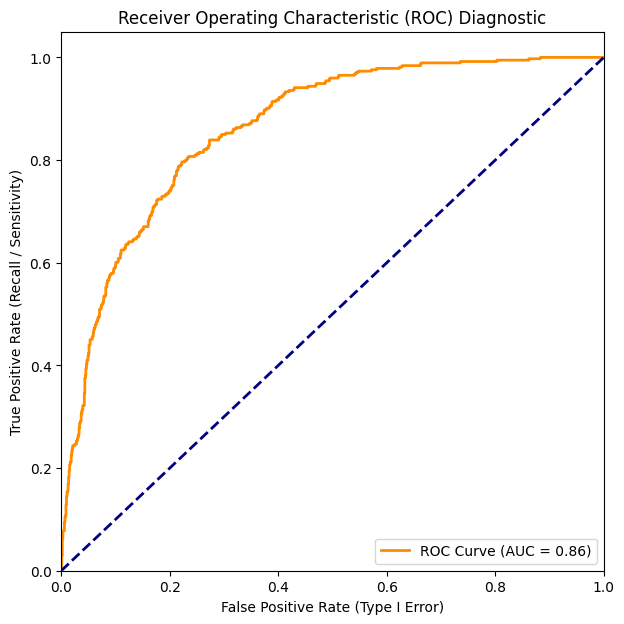

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# 1. ROC Curve Generation (Receiver Operating Characteristic)
fpr, tpr, thresholds = roc_curve(y_test, probabilities)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Receiver Operating Characteristic (ROC) Diagnostic')
plt.xlabel('False Positive Rate (Type I Error)')
plt.ylabel('True Positive Rate (Recall / Sensitivity)')
plt.legend(loc="lower right")
plt.show()



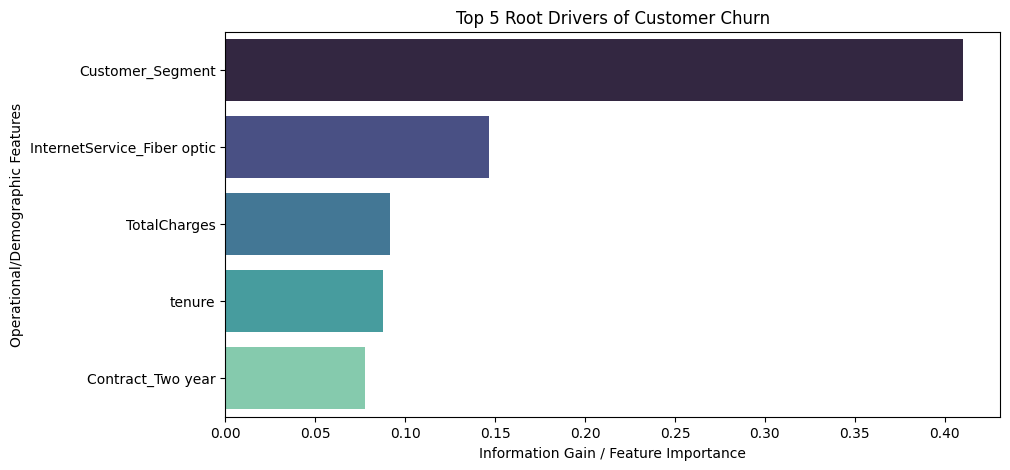

In [ ]:
# 2. Decision Tree Feature Importance / Root Drivers
dt_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dtree.feature_importances_
}).sort_values(by='Importance', ascending=False).head(5)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=dt_importance, palette='mako', legend=False)
plt.title('Top 5 Root Drivers of Customer Churn')
plt.xlabel('Information Gain / Feature Importance')
plt.ylabel('Operational/Demographic Features')
plt.show()